# Topic model evaluation 

This nb will look at evaluating the extracted topics, by applying measures of topic diversity and topic coherence. I think I could also calculate a square matrix of cosine similarity between all the topics. 

There are a few resources I followed for this: [https://towardsdatascience.com/understanding-topic-coherence-measures-4aa41339634c/](https://towardsdatascience.com/understanding-topic-coherence-measures-4aa41339634c/)

[https://radimrehurek.com/gensim/models/coherencemodel.html](https://radimrehurek.com/gensim/models/coherencemodel.html)

Some nice graphs of the model performance: [https://towardsdatascience.com/use-metrics-to-determine-lda-topic-model-size-1a1feaa1ff3c/](https://towardsdatascience.com/use-metrics-to-determine-lda-topic-model-size-1a1feaa1ff3c/)

Can use this for pairwise cosine similarity: ```from sklearn.metrics.pairwise import cosine_similarity```

Or I think I may need to use [OCTIS](https://github.com/mind-Lab/octis) package - [BERTopic discussion here](https://github.com/MaartenGr/BERTopic/discussions/627)

In [35]:
# Import necessary packages 
import pandas as pd
import numpy as np

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer

from bertopic.representation import MaximalMarginalRelevance, KeyBERTInspired

from octis.evaluation_metrics.diversity_metrics import TopicDiversity
from sklearn.metrics.pairwise import cosine_similarity

import ast 

from hdbscan import HDBSCAN
from umap import UMAP

from database.comments import Comments
from database.topics import Topics

import seaborn as sns
import matplotlib.pyplot as plt

import sys
sys.path.append('/root/comment_crunch/pipeline')
from nlp_tasks import NLP_Tasks

In [2]:
# load outputs/topic_model/full_bertopic/object_topics.csv
m1_topics_object = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/object_topics.csv')
m1_topics_object_embeddings = pd.read_csv('/root/comment_crunch/outputs/topic_model/full_bertopic/object_topic_embeddings.csv')

In [3]:
cs_topics = cosine_similarity(m1_topics_object_embeddings, m1_topics_object_embeddings)

In [4]:
cs_topics.shape

(2533, 2533)

In [5]:
cs_topics_reduced = cs_topics[1:21,1:21]

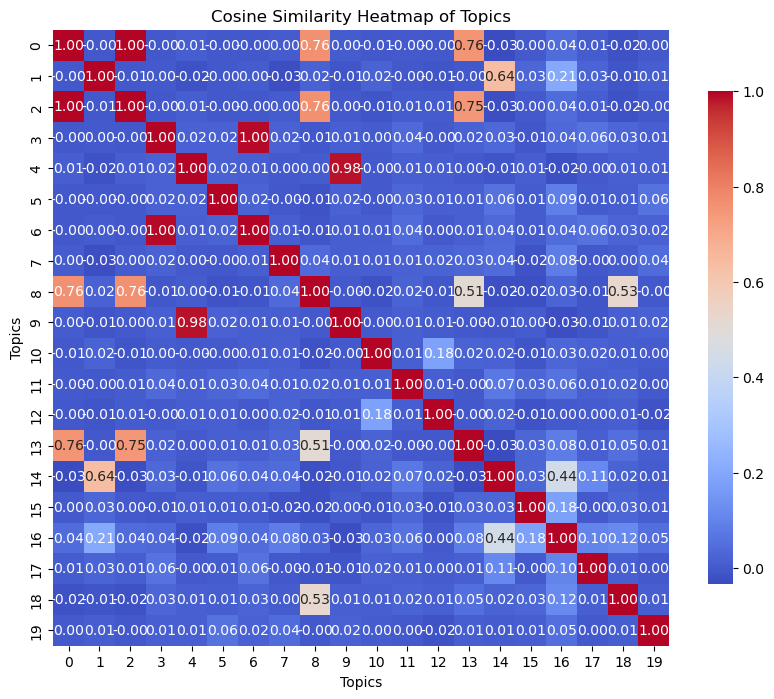

In [6]:
# plot heatmap of cosine similarity
plt.figure(figsize=(10, 8))
sns.heatmap(cs_topics_reduced, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Cosine Similarity Heatmap of Topics')
plt.xlabel('Topics')
plt.ylabel('Topics')
plt.show()

In [ ]:
# cs = Comments(env="dev")
# nlp_tasks = NLP_Tasks()
# df = cs.read_all()

# sentence_model = SentenceTransformer("Bea-Taylor/objection_fine_tuned_4")

# df_objects = df[df['stance']=='Objects']
# df_objects_split = nlp_tasks.split_text_on_newline(df=df_objects, column='cleaned_comment_text')
# max_length_tokens = sentence_model.get_max_seq_length()
# df_objects_split = nlp_tasks.split_text_by_length(df=df_objects_split, column='cleaned_comment_text', max_length=max_length_tokens, overlap=40, filter_empty=False, filter_short=False)
# cleaned_object_text = df_objects_split['cleaned_comment_text'].tolist()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


Device set to use cpu
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


Token indices sequence length is longer than the specified maximum sequence length for this model (287 > 256). Running this sequence through the model will result in indexing errors


In [8]:
# object_embeddings = sentence_model.encode(cleaned_object_text, show_progress_bar=True)

### Topic diveristy score for the full model (with the fine-tuned sentence transformer)

In [ ]:
topics_full_model_object = pd.read_csv(f'/root/comment_crunch/outputs/topic_model/full_bertopic/object_topics.csv')

topics_full_model_object_list = {'topics' : topics_full_model_object['Representation'].tolist()}
topics_full_model_object_list['topics'] =  [ast.literal_eval(item) for item in topics_full_model_object_list['topics']]

metric = TopicDiversity(topk=3) # Initialize metric
topic_diversity_score_full = metric.score(topics_full_model_object_list)
print(f"Topic Diversity Score: {topic_diversity_score_full}")

Topic Diversity Score: 0.6079747335175681


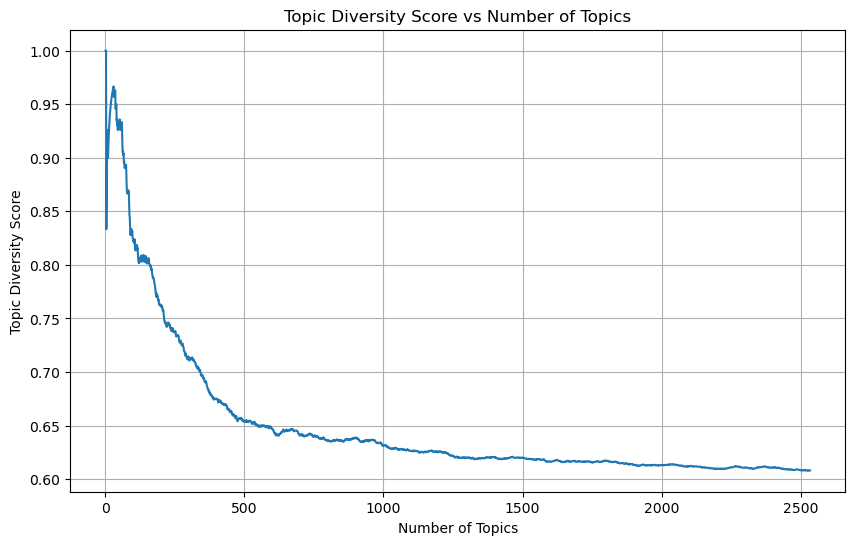

In [ ]:
num_topics = (range(1, len(topics_full_model_object_list['topics']) + 1))
diversity_scores = []

# Compute diversity score for each growing number of topics
for i in range(len(topics_full_model_object_list['topics'])):
    partial_topics = topics_full_model_object_list['topics'][:i+1]
    score = metric.score({'topics': partial_topics})
    diversity_scores.append(score)

# Create a DataFrame for plotting
import pandas as pd
df_plot = pd.DataFrame({
    'num_topics': num_topics,
    'diversity_score': diversity_scores
})

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='num_topics', y='diversity_score', data=df_plot)
plt.title('Topic Diversity Score vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Topic Diversity Score')
plt.grid(True)
plt.show()


In [39]:
topics_full_model_support = pd.read_csv(f'/root/comment_crunch/outputs/topic_model/full_bertopic/supports_topics.csv')    

topics_full_model_support_list = {'topics' : topics_full_model_support['Representation'].tolist()}
topics_full_model_support_list['topics'] =  [ast.literal_eval(item) for item in topics_full_model_support_list['topics']]

metric = TopicDiversity(topk=3) # Initialize metric
topic_diversity_score_full_support = metric.score(topics_full_model_support_list)
print(f"Topic Diversity Score (Support): {topic_diversity_score_full_support}")

Topic Diversity Score (Support): 0.7325349301397206


In [40]:
topics_full_model_neutral = pd.read_csv(f'/root/comment_crunch/outputs/topic_model/full_bertopic/neutral_topics.csv')

topics_full_model_neutral_list = {'topics' : topics_full_model_neutral['Representation'].tolist()}
topics_full_model_neutral_list['topics'] =  [ast.literal_eval(item) for item in topics_full_model_neutral_list['topics']]

metric = TopicDiversity(topk=3) # Initialize metric
topic_diversity_score_full_neutral = metric.score(topics_full_model_neutral_list)
print(f"Topic Diversity Score (Neutral): {topic_diversity_score_full_neutral}")

Topic Diversity Score (Neutral): 0.7913486005089059


### Topic diveristy score for the full model (with the baseline sentence transformer)

In [37]:
topics_base_model_object = pd.read_csv(f'/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/object_topics.csv')

topics_base_model_object_list = {'topics' : topics_base_model_object['Representation'].tolist()}
topics_base_model_object_list['topics'] =  [ast.literal_eval(item) for item in topics_base_model_object_list['topics']]

metric = TopicDiversity(topk=3) # Initialize metric
topic_diversity_score_base = metric.score(topics_base_model_object_list)
print(f"Topic Diversity Score: {topic_diversity_score_base}")

Topic Diversity Score: 0.6559466019417476


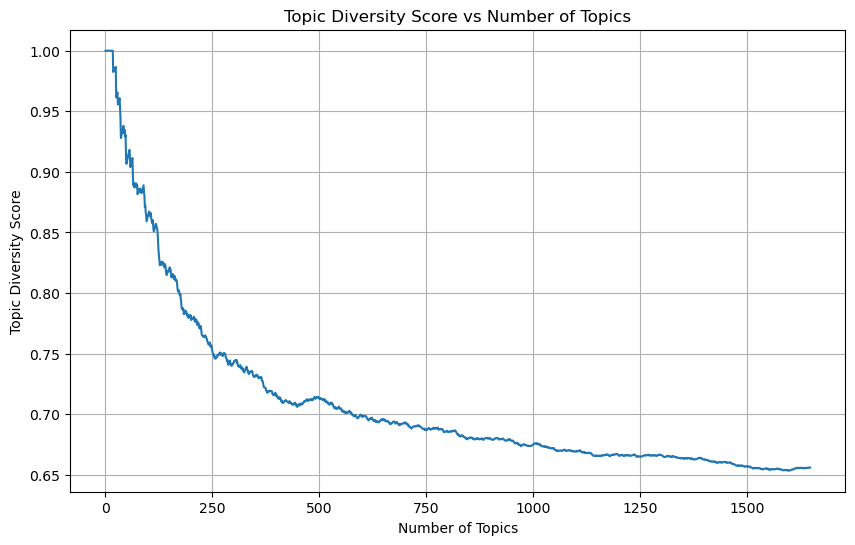

In [50]:
num_topics = (range(1, len(topics_base_model_object_list['topics']) + 1))
diversity_scores = []

# Compute diversity score for each growing number of topics
for i in range(len(topics_base_model_object_list['topics'])):
    partial_topics = topics_base_model_object_list['topics'][:i+1]
    score = metric.score({'topics': partial_topics})
    diversity_scores.append(score)

# Create a DataFrame for plotting
import pandas as pd
df_plot = pd.DataFrame({
    'num_topics': num_topics,
    'diversity_score': diversity_scores
})

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(x='num_topics', y='diversity_score', data=df_plot)
plt.title('Topic Diversity Score vs Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Topic Diversity Score')
plt.grid(True)
plt.show()


In [41]:
topics_base_model_support = pd.read_csv(f'/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/supports_topics.csv')

topics_base_model_support_list = {'topics' : topics_base_model_support['Representation'].tolist()}
topics_base_model_support_list['topics'] =  [ast.literal_eval(item) for item in topics_base_model_support_list['topics']]

metric = TopicDiversity(topk=3) # Initialize metric
topic_diversity_score_base_support = metric.score(topics_base_model_support_list)
print(f"Topic Diversity Score (Support): {topic_diversity_score_base_support}")

Topic Diversity Score (Support): 0.8063725490196079


In [42]:
topics_base_model_neutral = pd.read_csv(f'/root/comment_crunch/outputs/topic_model/full_bertopic_baseline_st/neutral_topics.csv') 

topics_base_model_neutral_list = {'topics' : topics_base_model_neutral['Representation'].tolist()}
topics_base_model_neutral_list['topics'] =  [ast.literal_eval(item) for item in topics_base_model_neutral_list['topics']]

metric = TopicDiversity(topk=3) # Initialize metric
topic_diversity_score_base_neutral = metric.score(topics_base_model_neutral_list)
print(f"Topic Diversity Score (Neutral): {topic_diversity_score_base_neutral}")

Topic Diversity Score (Neutral): 0.8803418803418803
